In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from Tracer import WindField, Trajectory
from Tracer.solvers import solver_rk45, solver_euler

In [27]:
# Rans file and standard conditions
filepath = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_corr.nc'

U_ref = 6    # [m/s]
z0 = 0.0039   # [m]
wd = 0      # [deg]

# --- Wind field definitions ---
rw = WindField(profile='rans', ds=filepath,U_ref=U_ref)
lw = WindField(profile='log', U_ref=U_ref, z0=z0, direction=wd)
uw = WindField(profile='uniform', U_ref=U_ref, direction=wd)

Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.0039, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0


In [38]:
point = np.array([10,40]) #x,y coords for the point of interest

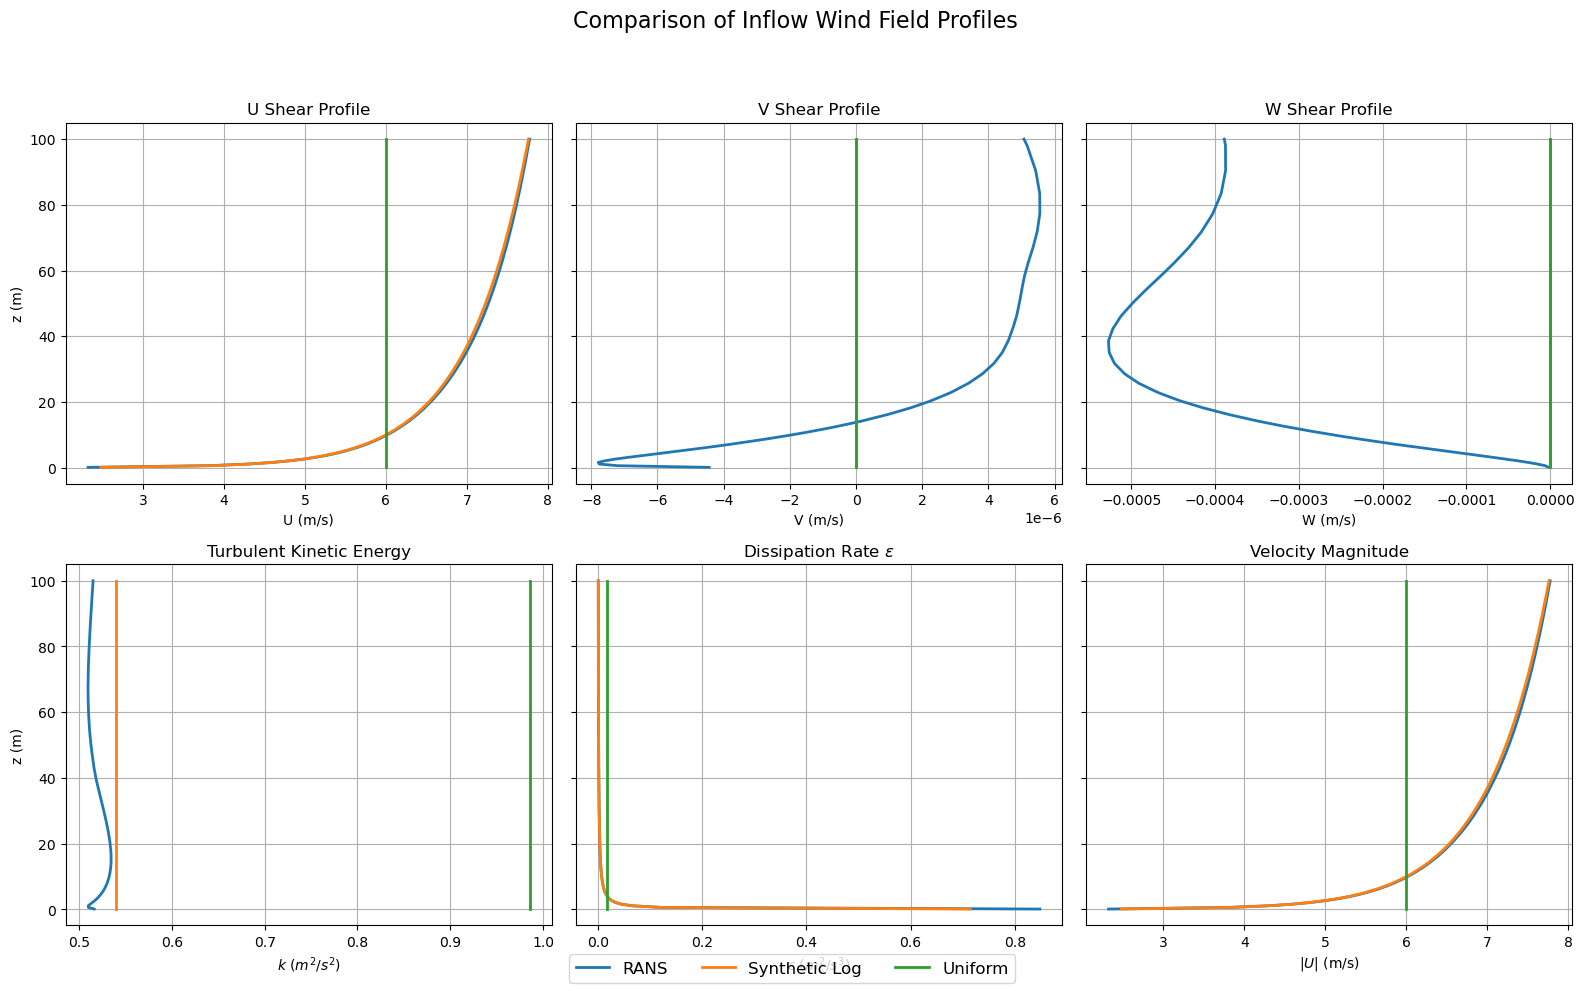

In [39]:
z_vals = np.linspace(0.1, 100, 200)

urw = np.zeros(len(z_vals))
vrw = np.zeros(len(z_vals))
wrw = np.zeros(len(z_vals))
krw = np.zeros(len(z_vals))
erw = np.zeros(len(z_vals))

ulw = np.zeros(len(z_vals))
vlw = np.zeros(len(z_vals))
wlw = np.zeros(len(z_vals))
klw = np.zeros(len(z_vals))
elw = np.zeros(len(z_vals))

uuw = np.zeros(len(z_vals))
vuw = np.zeros(len(z_vals))
wuw = np.zeros(len(z_vals))
kuw = np.zeros(len(z_vals))
euw = np.zeros(len(z_vals))

for i, z in enumerate(z_vals):

    # --- RANS ---
    vel, krw[i], erw[i] = rw.get_profile_at(x=point[0], y=point[1], z=z)
    urw[i], vrw[i], wrw[i] = vel

    # --- Synthetic Log ---
    vel, klw[i], elw[i] = lw.get_profile_at(x=point[0], y=point[1], z=z)
    ulw[i], vlw[i], wlw[i] = vel

    # --- Uniform ---
    vel, kuw[i], euw[i] = uw.get_profile_at(x=point[0], y=point[1], z=z)
    uuw[i], vuw[i], wuw[i] = vel

# ---------------------------------------------------
fig, axs = plt.subplots(2, 3, figsize=(16, 10), sharey=True)

# ===== First Row =====
# U shear
axs[0,0].plot(urw, z_vals, linewidth=2, label='RANS')
axs[0,0].plot(ulw, z_vals, linewidth=2, label='Synthetic Log')
axs[0,0].plot(uuw, z_vals, linewidth=2, label='Uniform')
axs[0,0].set_xlabel('U (m/s)')
axs[0,0].set_ylabel('z (m)')
axs[0,0].set_title('U Shear Profile')

axs[0,0].grid(True)

# V shear
axs[0,1].plot(vrw, z_vals, linewidth=2)
axs[0,1].plot(vlw, z_vals, linewidth=2)
axs[0,1].plot(vuw, z_vals, linewidth=2)
axs[0,1].set_xlabel('V (m/s)')
axs[0,1].set_title('V Shear Profile')

axs[0,1].grid(True)

# W shear
axs[0,2].plot(wrw, z_vals, linewidth=2)
axs[0,2].plot(wlw, z_vals, linewidth=2)
axs[0,2].plot(wuw, z_vals, linewidth=2)
axs[0,2].set_xlabel('W (m/s)')
axs[0,2].set_title('W Shear Profile')
axs[0,2].grid(True)


# ===== Second Row =====
# TKE
axs[1,0].plot(krw, z_vals, linewidth=2)
axs[1,0].plot(klw, z_vals, linewidth=2)
axs[1,0].plot(kuw, z_vals, linewidth=2)
axs[1,0].set_xlabel(r'$k$ ($m^2/s^2$)')
axs[1,0].set_ylabel('z (m)')
axs[1,0].set_title('Turbulent Kinetic Energy')
axs[1,0].grid(True)

# epsilon
axs[1,1].plot(erw, z_vals, linewidth=2)
axs[1,1].plot(elw, z_vals, linewidth=2)
axs[1,1].plot(euw, z_vals, linewidth=2)
axs[1,1].set_xlabel(r'$\varepsilon$ ($m^2/s^3$)')
axs[1,1].set_title(r'Dissipation Rate $\varepsilon$')
axs[1,1].grid(True)

# Velocity magnitude panel (nice use of 6th slot)
Umag_rw = np.sqrt(urw**2 + vrw**2 + wrw**2)
Umag_lw = np.sqrt(ulw**2 + vlw**2 + wlw**2)
Umag_uw = np.sqrt(uuw**2 + vuw**2 + wuw**2)

axs[1,2].plot(Umag_rw, z_vals, linewidth=2)
axs[1,2].plot(Umag_lw, z_vals, linewidth=2)
axs[1,2].plot(Umag_uw, z_vals, linewidth=2)
axs[1,2].set_xlabel(r'$|U|$ (m/s)')
axs[1,2].set_title('Velocity Magnitude')
axs[1,2].grid(True)

# Global legend
fig.legend(['RANS', 'Synthetic Log', 'Uniform'],
           loc='lower center',
           ncol=3,
           fontsize=12,
           frameon=True)

fig.suptitle('Comparison of Inflow Wind Field Profiles', fontsize=16)

plt.tight_layout(rect=[0,0,1,0.94])
plt.show()